In [8]:
import os
import sys
import yaml
import json
import numpy as np
import polars as pl
import pandas as pd
from tqdm import tqdm
import statsmodels.api as sm

from anngeno import AnnGeno
import multiprocessing

from plotnine import *
from IPython.display import display

from sklearn.metrics import roc_auc_score

num_cores = multiprocessing.cpu_count()
print(num_cores)

16


## Extract genotype and phenotype data

In [9]:
def sigmoid(z):
    return 1/(1 + np.exp(-z))

def process_phenotypes_prs_long(
    gene_trait_df: pl.DataFrame,
    pheno_path: str,
    prs_path: str,
    cov_path: str,
    config: dict,
) -> pl.DataFrame:
    """
    Process phenotypes and PRS, compute residuals for each phenotype, and return a long-format Polars DataFrame.
    """
    print("Process phenotypes and PRS, compute residuals for each phenotype, and return a long-format Polars DataFrame.")
    
    # --- Step 1: Unique phenotypes ---
    unique_phenotypes = gene_trait_df['phenotype'].unique().to_list()
    if not unique_phenotypes:
        raise ValueError("No phenotypes found in gene_trait_df")

    # --- Step 2: Read data lazily ---
    phenos_lazy = (
        pl.scan_parquet(pheno_path)
        .rename({'IID': 'individual'})
        .select(['individual'] + unique_phenotypes)
        .drop_nulls()
    )

    prs_cols = [f"{pheno}_int_prs" for pheno in unique_phenotypes]
    prs_lazy = (
        pl.scan_parquet(prs_path)
        .rename({'IID': 'individual'})
        .select(['individual'] + prs_cols)
        .drop_nulls()
    )

    cov_list = config.get("covariates", [])
    cov_lazy = (
        pl.scan_parquet(cov_path)
        .rename({'sample': 'individual'})
        .select(['individual'] + cov_list)
        .with_columns(pl.col('individual').cast(pl.Int64))
    )

    # --- Step 3: Merge all into one lazy DataFrame ---
    all_lazy = phenos_lazy.join(prs_lazy, on='individual', how='inner').join(
        cov_lazy, on='individual', how='inner'
    )
    
    # Collect once for regression computations (still needed for statsmodels)
    all_pd = all_lazy.collect().to_pandas()

    # --- Step 4: Compute residuals ---
    all_residuals_dfs = []

    for phenotype in unique_phenotypes:
        try:
            pheno_cols = [phenotype, f"{phenotype}_int_prs"] + cov_list
            temp_df = all_pd[['individual'] + pheno_cols].dropna()
            if len(temp_df) == 0:
                print(f"No data for phenotype: {phenotype}")
                continue

            y = temp_df[phenotype]
            X = temp_df.drop(columns=[phenotype, 'individual'])
            X = sm.add_constant(X)

            # model = sm.OLS(y, X).fit()
            # residuals = pd.Series(model.resid, index=temp_df.index, name=f"{phenotype}_residual")
            
            model = sm.GLM(y, X, family=sm.families.Binomial()).fit()
            residuals = pd.Series(model.resid_deviance, index=temp_df.index, name=f"{phenotype}_residual")
            
            pheno_residuals = pd.concat([temp_df[['individual']], residuals], axis=1)
            all_residuals_dfs.append(pheno_residuals)

        except Exception as e:
            print(f"Error processing phenotype {phenotype}: {e}")
            continue

    if not all_residuals_dfs:
        raise ValueError("No residuals could be computed")

    # --- Step 5: Convert to long-format lazy DataFrame ---
    long_lazy_dfs = []
    for residual_df in all_residuals_dfs:
        p_wide_lazy = pl.LazyFrame(residual_df).with_columns(
            pl.col('individual').cast(pl.String)
        )
        pheno_cols = [c for c in residual_df.columns if c.endswith('_residual')]
        pdf_lazy = (
            p_wide_lazy.unpivot(
                index=['individual'],
                on=pheno_cols,
                variable_name='phenotype',
                value_name='pheno_value',
            )
            .with_columns(
                pl.col('phenotype').str.replace('_residual', '').alias('phenotype')
            )
        )
        long_lazy_dfs.append(pdf_lazy)

    combined_pdf_lazy = pl.concat(long_lazy_dfs) if len(long_lazy_dfs) > 1 else long_lazy_dfs[0]

    return combined_pdf_lazy.collect()


def process_gene_genotypes(
    gene_id: str, 
    regions_dict: dict, 
    sample_list: list
) -> pl.LazyFrame:
    """
    Extract genotypes for a specific gene and return as lazy DataFrame
    """
    try:
        reg_dict = regions_dict[gene_id]
        geno = reg_dict['genotypes']
        
        # Find heterozygous genotypes (genotype == 1)
        rows, cols = np.where(geno == 1)
        het = pl.DataFrame({
            'id': np.array(reg_dict['variant_ids'])[rows],
            'individual': np.array(sample_list)[cols],
            'genotype': 1
        })
        
        # Find homozygous genotypes (genotype == 2)
        rows, cols = np.where(geno == 2)
        hom = pl.DataFrame({
            'id': np.array(reg_dict['variant_ids'])[rows],
            'individual': np.array(sample_list)[cols],
            'genotype': 2
        })
        
        geno_melt_lazy = pl.concat([het, hom]).lazy().with_columns(
            pl.lit(gene_id).alias('region')
        )
        
        return geno_melt_lazy
        
    except Exception as e:
        print(f"Error processing genotypes for gene {gene_id}: {e}")
        return None


def get_geno_pheno(
    gene_trait_df: pl.DataFrame,
    anngeno_path: str,
    pheno_path: str,
    prs_path: str,
    cov_path: str,
    new_annotations_path: str,
    config: dict,
    prs_correction: bool = True,
    maf: float = None,
    eur_samples_path: str = None,
    only_missense_vars: bool = False,
    all_vars: bool = False,
):
    """
    Main processing pipeline for extracting the gene-phenotype data as one dataframe.
    """

    if prs_correction:
        # Process phenotypes (PRS + covariate correction)
        combined_pdf = process_phenotypes_prs_long(
            gene_trait_df,
            pheno_path,
            prs_path,
            cov_path,
            config,
        )
    else:
        cov_list = ['age', 'sex']
        cov_lazy = (
            pl.read_parquet(cov_path)
            .rename({'sample': 'individual'})
            .select(['individual'] + cov_list)
            .with_columns(pl.col('individual').cast(pl.Int64))
        )
        unique_phenotypes = gene_trait_df['phenotype'].unique().to_list()
        combined_pdf = (
            pl.read_parquet(pheno_path)            
            .rename({'IID': 'individual'})
            .join(cov_lazy, on='individual')
            .select(['individual'] + cov_list + unique_phenotypes)
            .drop_nulls()
            .unpivot(
                index=['individual'] + cov_list,
                on=unique_phenotypes,
                variable_name='phenotype',
                value_name='pheno_value',
            ).with_columns(
            pl.col('individual').cast(pl.String)
            )
        )
    
    # Convert to lazy for downstream processing
    combined_pdf_lazy = pl.LazyFrame(combined_pdf)

    # Initialize AnnGeno
    print("Loading AnnGeno...")
    ag = AnnGeno(anngeno_path, mode='r', low_mem=True)

    if maf:
        variants_to_keep = (
            ag.annotations.filter(pl.col('af_ukb') <= maf)
            .select('id')
            .collect()['id']
        )
        ag.subset_variants(set(variants_to_keep))

    eur_samples = None
    if eur_samples_path:
        eur_samples = pl.read_csv(eur_samples_path).with_columns(
            pl.col("eid").cast(pl.Utf8)
        )['eid'].to_list()
        ag.subset_samples(set(eur_samples))

    # Get regions
    unique_genes = gene_trait_df['gene_id'].unique().to_list()
    regions_dict = ag.get_many_regions(unique_genes)

    # Load new scores lazily
    new_anno = None
    if new_annotations_path:
        print("Adding new scores to benchmark...")
        new_anno = (
            pl.read_parquet(new_annotations_path)
            .filter(pl.col('region').is_in(unique_genes))
        )

    # Collect annotation categories
    all_annotation_list = []
    rare_variant_annotations_dict = config.get("rare_variant_annotations")
    if rare_variant_annotations_dict:
        for category in rare_variant_annotations_dict.values():
            all_annotation_list.extend(category)

    all_results_lazy = []
    pheno_gis_df = None  # last computed pheno_gis_df, useful when plotting for a single gene-trait pair

    gene_to_traits = (
        gene_trait_df.group_by("gene_id")
        .agg(pl.col("phenotype").unique().alias("phenotypes"))
    )

    gene_pheno_df_list = []

    # --- Loop by gene, compute genotypes once ---
    for row in tqdm(gene_to_traits.iter_rows(named=True), total=len(gene_to_traits)):
        gene_id = row["gene_id"]
        phenotypes = row["phenotypes"]

        print(f"Processing gene {gene_id} with {len(phenotypes)} phenotypes")

        geno_melt_lazy = process_gene_genotypes(gene_id, regions_dict, ag.samples)
        if geno_melt_lazy is None:
            print(f"No genotype data for {gene_id}")
            continue

        anno_df_lazy = pl.LazyFrame(regions_dict[gene_id]["annotations"])

        # Handle new annotations
        if new_annotations_path and new_anno is not None:
            new_anno_gene_lazy = (
                new_anno
                .filter(pl.col("region") == gene_id)
                .pivot(
                    index=['id', 'region', 'gene_name'],
                    on='assay_name',
                    values='score'
                )
                .drop_nulls()
                .lazy()
            )

        # --- Loop over phenotypes for this gene ---
        for phenotype in phenotypes:
            print(f" -> {gene_id} - {phenotype}")

            pheno_data_lazy = combined_pdf_lazy.filter(pl.col("phenotype") == phenotype)
            
            # Check if we have phenotype data before proceeding
            if pheno_data_lazy.select(pl.len()).collect().item() == 0:
                print(f"No phenotype data for {phenotype}")
                continue

            gp_lazy = geno_melt_lazy.join(pheno_data_lazy, on="individual")

            if eur_samples is not None:
                gp_lazy = gp_lazy.filter(pl.col("individual").is_in(eur_samples))

            gp_lazy = gp_lazy.filter(pl.col("genotype") == 1)
            
            # Check if we have valid data before proceeding
            if gp_lazy.select(pl.len()).collect().item() == 0:
                print(f"No valid genotype-phenotype data for {gene_id} - {phenotype}")
                continue

            # Prepare annotations
            if new_annotations_path and new_anno is not None:
                new_anno_gene_collected = new_anno_gene_lazy.collect()
                if 'id' in new_anno_gene_collected.columns:
                    anno_wide_lazy = anno_df_lazy.join(new_anno_gene_lazy, on='id', how='inner')
                elif 'mutant' in new_anno_gene_collected.columns:
                    anno_wide_lazy = anno_df_lazy.join(new_anno_gene_lazy, on='mutant', how='inner')
                else:
                    print(f"No matching column for joining new annotations for {gene_id}")
                    continue
                # Get available annotations (need to collect briefly to check columns)
                temp_collected = anno_wide_lazy.select(pl.all().head(1)).collect()
                available_annotations = list(set(all_annotation_list) & set(temp_collected.columns)) + new_anno_gene_collected.columns[3:]
            else:
                anno_wide_lazy = anno_df_lazy
                # Get available annotations (need to collect briefly to check columns)
                temp_collected = anno_wide_lazy.select(pl.all().head(1)).collect()
                available_annotations = list(set(all_annotation_list) & set(temp_collected.columns))

            if not available_annotations:
                print(f"No valid annotations for {gene_id}")
                continue

            if only_missense_vars:
                anno_wide_lazy = anno_wide_lazy.filter(pl.col('consequence_missense_variant') == 1)

            anno_melt_lazy = anno_wide_lazy.unpivot(
                index=['id', 'region', 'af_ukb'],
                on=available_annotations,
                variable_name='annotation',
                value_name='score',
            ).with_columns(
                score =pl.col('score').cast(pl.Float32)
            )

            ## Add all variant scores
            if all_vars:
                temp_anno_collected = anno_df_lazy.select(pl.all().head(1)).collect()
                annos_all_vars = list(set(all_annotation_list) & set(temp_anno_collected.columns))
                all_anno_melt_lazy = (
                    anno_df_lazy
                    .unpivot(
                        index=['id', 'region'],
                        on=annos_all_vars,
                        variable_name='annotation',
                        value_name='score',
                    )
                    .with_columns(
                        annotation = (pl.col('annotation') + "_allvars")
                    )
                )
                anno_melt_lazy = pl.concat([anno_melt_lazy, all_anno_melt_lazy])

            gpa_lazy = gp_lazy.join(anno_melt_lazy, on='id', how='inner')
            
            # Check if we have data after joining annotations
            if gpa_lazy.select(pl.len()).collect().item() == 0:
                print(f"No data after joining annotations for {gene_id} - {phenotype}")
                continue
            
            gene_pheno_df_list.append(gpa_lazy)
    
    gene_pheno_df = pl.concat(gene_pheno_df_list).collect(engine='streaming')
    return gene_pheno_df

In [10]:
# Configuration and paths
corr_method = 'spearman'
trait_type = 'quantitative'

config_path = f'/home/dnanexus/ukbgym/config.yaml'
with open(config_path) as f:
    config = yaml.safe_load(f)

# pheno_path = '/home/dnanexus/data_dir/phenotypes/phenotypes190_missing20_unique2_int.parquet'
pheno_path = '/home/dnanexus/data_dir/phenotypes/phenotypes190_missing20_unique2_int_female.parquet'
prs_path = '/home/dnanexus/data_dir/phenotypes/PRS190_EUR_missing20_unique2_int.parquet'
cov_path = '/home/dnanexus/data_dir/phenotypes/250709_quant_phenotypes_covariates_genetic_pcs_prs_corrected.parquet'
eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'
anngeno_path = '/home/dnanexus/data_dir/dms_coding.ag'

exp_data_path = '/home/dnanexus/data_dir/exp_data/BRCA1_BRCA2_SGE_combined.parquet'
save_path = None

maf=1e-3
n = !wc -l $eur_samples_path
n_eur = int(n[0].split(' ')[0])
mac = maf*(2*n_eur)

# Use a list comprehension to flatten the nested dictionary into records
records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records)
all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()

gene_trait_df = pl.DataFrame({
    'gene_id': ["ENSG00000139618"], #BRCA2 ["ENSG00000012048"], #BRCA1
    'phenotype': ["jurgens_breast_cancer"]
})

pheno_gis_df = get_geno_pheno(
    gene_trait_df=gene_trait_df,
    anngeno_path=anngeno_path,
    pheno_path=pheno_path,
    prs_path=prs_path,
    cov_path=cov_path,
    new_annotations_path=exp_data_path,
    config=config,
    maf=maf,
    eur_samples_path=eur_samples_path,
    prs_correction=False,
    only_missense_vars=True,
    all_vars=False,
)

pheno_gis_df

Loading AnnGeno...


/home/dnanexus/deeprvat2-env/lib/python3.11/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
100%|██████████| 490541/490541 [00:00<00:00, 2597507.73it/s]


Adding new scores to benchmark...


  0%|          | 0/1 [00:00<?, ?it/s]

Processing gene ENSG00000139618 with 1 phenotypes


100%|██████████| 1/1 [00:06<00:00,  6.42s/it]

 -> ENSG00000139618 - jurgens_breast_cancer


id,individual,genotype,region,age,sex,phenotype,pheno_value,region_right,af_ukb,annotation,score
str,str,i32,str,i8,f64,str,f32,str,f32,str,f32
"""chr13:32363417:G:T""","""3760053""",1,"""ENSG00000139618""",55,0.0,"""jurgens_breast_cancer""",0.0,"""ENSG00000139618""",0.00001,"""gpn_score""",0.79
"""chr13:32363417:G:T""","""3760053""",1,"""ENSG00000139618""",55,0.0,"""jurgens_breast_cancer""",0.0,"""ENSG00000139618""",0.00001,"""cadd_raw""",0.922218
"""chr13:32363417:G:T""","""3760053""",1,"""ENSG00000139618""",55,0.0,"""jurgens_breast_cancer""",0.0,"""ENSG00000139618""",0.00001,"""zooverphylop""",1.692
"""chr13:32363417:G:T""","""3760053""",1,"""ENSG00000139618""",55,0.0,"""jurgens_breast_cancer""",0.0,"""ENSG00000139618""",0.00001,"""am_pathogenicity""",0.0772
"""chr13:32363417:G:T""","""3760053""",1,"""ENSG00000139618""",55,0.0,"""jurgens_breast_cancer""",0.0,"""ENSG00000139618""",0.00001,"""verphylop""",1.55
…,…,…,…,…,…,…,…,…,…,…,…
"""chr13:32379412:G:T""","""2133796""",1,"""ENSG00000139618""",46,0.0,"""jurgens_breast_cancer""",0.0,"""ENSG00000139618""",0.000927,"""am_pathogenicity""",0.3861
"""chr13:32379412:G:T""","""2133796""",1,"""ENSG00000139618""",46,0.0,"""jurgens_breast_cancer""",0.0,"""ENSG00000139618""",0.000927,"""verphylop""",2.51
"""chr13:32379412:G:T""","""2133796""",1,"""ENSG00000139618""",46,0.0,"""jurgens_breast_cancer""",0.0,"""ENSG00000139618""",0.000927,"""esmscoremissense""",-4.83


In [25]:
records = [
    {
        "annotation": anno,
        "label": props["label"],
        "category": category,
        "annotation_dir": props.get("direction", 1),
        "color": props["color"],
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records)#.select(['annotation', 'label', 'annotation_dir'])
all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()

exp_annos = pl.DataFrame({
    "annotation": ["SGE_EScell", "SGE_HAP1"],
    "label": ["SGE EScell", "SGE HAP1"],
    "category": ["SGE", "SGE"],
    "annotation_dir": [-1, -1],
    "color": ["gray", "black"]
})

anno_config_df = pl.concat([anno_config_df, exp_annos]).unique(subset=['annotation'])
anno_config_df

annotation,label,category,annotation_dir,color
str,str,str,i64,str
"""am_pathogenicity""","""AlphaMissense""","""missense""",1,"""#e76e5b"""
"""cadd_raw""","""CADD Raw""","""genetic_diversity""",1,"""#1f77b4"""
"""gpn_score""","""GPN-MSA""","""conservation""",-1,"""#942c80"""
"""verphylop""","""Vertebrate PhyloP""","""conservation""",1,"""#440154"""
"""SGE_HAP1""","""SGE HAP1""","""SGE""",-1,"""black"""
"""esmscoremissense""","""ESM1v""","""missense""",-1,"""#feb72d"""
"""SGE_EScell""","""SGE EScell""","""SGE""",-1,"""gray"""
"""zooverphylop""","""Zoonomia vertebrate PhyloP""","""conservation""",1,"""#6a1c81"""


In [26]:
pheno_gis_df[['id', 'region', 'annotation', 'score']].unique().join(
        anno_config_df, 
        on='annotation', 
        how='left'
    )

id,region,annotation,score,label,category,annotation_dir,color
str,str,str,f32,str,str,i64,str
"""chr13:32356485:A:C""","""ENSG00000139618""","""cadd_raw""",4.242322,"""CADD Raw""","""genetic_diversity""",1,"""#1f77b4"""
"""chr13:32357875:G:A""","""ENSG00000139618""","""SGE_EScell""",-0.026194,"""SGE EScell""","""SGE""",-1,"""gray"""
"""chr13:32362615:C:G""","""ENSG00000139618""","""SGE_HAP1""",0.268015,"""SGE HAP1""","""SGE""",-1,"""black"""
"""chr13:32363241:A:G""","""ENSG00000139618""","""SGE_HAP1""",0.269803,"""SGE HAP1""","""SGE""",-1,"""black"""
"""chr13:32394703:G:A""","""ENSG00000139618""","""esmscoremissense""",-3.467,"""ESM1v""","""missense""",-1,"""#feb72d"""
…,…,…,…,…,…,…,…
"""chr13:32363187:C:T""","""ENSG00000139618""","""SGE_EScell""",-0.628148,"""SGE EScell""","""SGE""",-1,"""gray"""
"""chr13:32363507:G:C""","""ENSG00000139618""","""esmscoremissense""",-3.547,"""ESM1v""","""missense""",-1,"""#feb72d"""
"""chr13:32363427:A:G""","""ENSG00000139618""","""zooverphylop""",-0.791,"""Zoonomia vertebrate PhyloP""","""conservation""",1,"""#6a1c81"""


id,region,phenotype,annotation,score,label,category,annotation_dir,color,n_variants,score_dircorr,score_rank,score_rank_dircorr,max_score_rank,score_ptile,score_ptile_dircorr
str,str,str,str,f32,str,str,i64,str,u64,f64,f64,f64,f64,f64,f64
"""chr13:32371043:C:A""","""ENSG00000139618""","""jurgens_breast_cancer""","""zooverphylop""",4.189,"""Zoonomia vertebrate PhyloP""","""conservation""",1,"""#6a1c81""",225,4.189,134.0,134.0,221.5,0.604966,0.604966
"""chr13:32363369:G:C""","""ENSG00000139618""","""jurgens_breast_cancer""","""esmscoremissense""",-6.9,"""ESM1v""","""missense""",-1,"""#feb72d""",225,6.9,2.0,224.0,225.0,0.008889,0.995556
"""chr13:32371040:C:A""","""ENSG00000139618""","""jurgens_breast_cancer""","""SGE_HAP1""",0.117921,"""SGE HAP1""","""SGE""",-1,"""black""",225,-0.117921,112.0,114.0,225.0,0.497778,0.506667
"""chr13:32356461:T:C""","""ENSG00000139618""","""jurgens_breast_cancer""","""SGE_HAP1""",0.086308,"""SGE HAP1""","""SGE""",-1,"""black""",225,-0.086308,83.0,143.0,225.0,0.368889,0.635556
"""chr13:32376705:C:A""","""ENSG00000139618""","""jurgens_breast_cancer""","""am_pathogenicity""",0.1057,"""AlphaMissense""","""missense""",1,"""#e76e5b""",225,0.1057,73.0,73.0,225.0,0.324444,0.324444
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""chr13:32357883:C:G""","""ENSG00000139618""","""jurgens_breast_cancer""","""SGE_HAP1""",0.133456,"""SGE HAP1""","""SGE""",-1,"""black""",225,-0.133456,130.0,96.0,225.0,0.577778,0.426667
"""chr13:32363406:C:G""","""ENSG00000139618""","""jurgens_breast_cancer""","""verphylop""",5.467,"""Vertebrate PhyloP""","""conservation""",1,"""#440154""",225,5.467,161.0,161.0,225.0,0.715556,0.715556
"""chr13:32362632:C:G""","""ENSG00000139618""","""jurgens_breast_cancer""","""verphylop""",7.437,"""Vertebrate PhyloP""","""conservation""",1,"""#440154""",225,7.437,187.0,187.0,225.0,0.831111,0.831111


In [47]:
# pheno_gis_dircorr = (
#     pheno_gis_df.join(
#         anno_config_df, 
#         on='annotation', 
#         how='left'
#     )
#     .with_columns(
#         annotation_dir = pl.col('annotation_dir').fill_null(1),
#         label = pl.coalesce('label', 'annotation'),
#         n_variants = pl.col('id').n_unique(),
#     )
#     .with_columns(
#         score_dircorr = pl.col('score') * pl.col('annotation_dir'),
#     )
#     .with_columns(
#         score_rank = pl.col('score').rank("average").over(["region", "phenotype", "annotation"]),
#         score_rank_dircorr = pl.col('score_dircorr').rank("average").over(["region", "phenotype", "annotation"]),
#     )
#     .with_columns(
#         max_score_rank = pl.col('score_rank').max().over('annotation'),
#     )
#     .with_columns(
#         score_ptile = pl.col("score_rank") / pl.col("max_score_rank"),
#         score_ptile_dircorr = pl.col("score_rank_dircorr") / pl.col("max_score_rank"),
#     )
# )
# pheno_gis_dircorr

base_df = (
    pheno_gis_df.join(
        anno_config_df, 
        on='annotation', 
        how='left'
    )
    .with_columns(
        annotation_dir = pl.col('annotation_dir').fill_null(1),
        label = pl.coalesce('label', 'annotation'),
        n_variants = pl.col('id').n_unique(),
    )
    .with_columns(
        score_dircorr = pl.col('score') * pl.col('annotation_dir')
    )
)

variant_ranks = (
    base_df
    # Get one row per variant within each ranking group
    .unique(subset=['id', 'region', 'phenotype', 'annotation'])
    .with_columns(
        # Rank scores within each group
        score_rank = pl.col('score').rank("average").over(["region", "phenotype", "annotation"]),
        score_rank_dircorr = pl.col('score_dircorr').rank("average").over(["region", "phenotype", "annotation"]),
    )
    .with_columns(
        # The max rank is simply the count of unique variants in the group
        max_score_rank = pl.col('id').count().over(["region", "phenotype", "annotation"]),
    )
    .with_columns(
        # Calculate the percentile
        score_ptile = pl.col("score_rank") / pl.col("max_score_rank"),
        score_ptile_dircorr = pl.col("score_rank_dircorr") / pl.col("max_score_rank"),
    )
    # Select only the key columns and the final results to join back
    # .select(['id', 'region', 'phenotype', 'annotation', 'score_ptile', 'score_ptile_dircorr'])
)

# --- Step 3: Join the unique percentiles back to the full dataset ---
pheno_gis_dircorr = base_df.join(
    variant_ranks,
    on=['id', 'region', 'phenotype', 'annotation'],
    how='left'
)

pheno_gis_dircorr

id,individual,genotype,region,age,sex,phenotype,pheno_value,region_right,af_ukb,annotation,score,label,category,annotation_dir,color,n_variants,score_dircorr,individual_right,genotype_right,age_right,sex_right,pheno_value_right,region_right_right,af_ukb_right,score_right,label_right,category_right,annotation_dir_right,color_right,n_variants_right,score_dircorr_right,score_rank,score_rank_dircorr,max_score_rank,score_ptile,score_ptile_dircorr
str,str,i32,str,i8,f64,str,f32,str,f32,str,f32,str,str,i64,str,u64,f64,str,i32,i8,f64,f32,str,f32,f32,str,str,i64,str,u64,f64,f64,f64,u64,f64,f64
"""chr13:32363417:G:T""","""3760053""",1,"""ENSG00000139618""",55,0.0,"""jurgens_breast_cancer""",0.0,"""ENSG00000139618""",0.00001,"""gpn_score""",0.79,"""GPN-MSA""","""conservation""",-1,"""#942c80""",225,-0.79,"""3760053""",1,55,0.0,0.0,"""ENSG00000139618""",0.00001,0.79,"""GPN-MSA""","""conservation""",-1,"""#942c80""",225,-0.79,218.0,8.0,225,0.968889,0.035556
"""chr13:32363417:G:T""","""3760053""",1,"""ENSG00000139618""",55,0.0,"""jurgens_breast_cancer""",0.0,"""ENSG00000139618""",0.00001,"""cadd_raw""",0.922218,"""CADD Raw""","""genetic_diversity""",1,"""#1f77b4""",225,0.922218,"""3760053""",1,55,0.0,0.0,"""ENSG00000139618""",0.00001,0.922218,"""CADD Raw""","""genetic_diversity""",1,"""#1f77b4""",225,0.922218,25.0,25.0,225,0.111111,0.111111
"""chr13:32363417:G:T""","""3760053""",1,"""ENSG00000139618""",55,0.0,"""jurgens_breast_cancer""",0.0,"""ENSG00000139618""",0.00001,"""zooverphylop""",1.692,"""Zoonomia vertebrate PhyloP""","""conservation""",1,"""#6a1c81""",225,1.692,"""3760053""",1,55,0.0,0.0,"""ENSG00000139618""",0.00001,1.692,"""Zoonomia vertebrate PhyloP""","""conservation""",1,"""#6a1c81""",225,1.692,73.0,73.0,225,0.324444,0.324444
"""chr13:32363417:G:T""","""3760053""",1,"""ENSG00000139618""",55,0.0,"""jurgens_breast_cancer""",0.0,"""ENSG00000139618""",0.00001,"""am_pathogenicity""",0.0772,"""AlphaMissense""","""missense""",1,"""#e76e5b""",225,0.0772,"""3760053""",1,55,0.0,0.0,"""ENSG00000139618""",0.00001,0.0772,"""AlphaMissense""","""missense""",1,"""#e76e5b""",225,0.0772,34.0,34.0,225,0.151111,0.151111
"""chr13:32363417:G:T""","""3760053""",1,"""ENSG00000139618""",55,0.0,"""jurgens_breast_cancer""",0.0,"""ENSG00000139618""",0.00001,"""verphylop""",1.55,"""Vertebrate PhyloP""","""conservation""",1,"""#440154""",225,1.55,"""3760053""",1,55,0.0,0.0,"""ENSG00000139618""",0.00001,1.55,"""Vertebrate PhyloP""","""conservation""",1,"""#440154""",225,1.55,69.0,69.0,225,0.306667,0.306667
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""chr13:32379412:G:T""","""2133796""",1,"""ENSG00000139618""",46,0.0,"""jurgens_breast_cancer""",0.0,"""ENSG00000139618""",0.000927,"""am_pathogenicity""",0.3861,"""AlphaMissense""","""missense""",1,"""#e76e5b""",225,0.3861,"""3952115""",1,67,0.0,0.0,"""ENSG00000139618""",0.000927,0.3861,"""AlphaMissense""","""missense""",1,"""#e76e5b""",225,0.3861,168.0,168.0,225,0.746667,0.746667
"""chr13:32379412:G:T""","""2133796""",1,"""ENSG00000139618""",46,0.0,"""jurgens_breast_cancer""",0.0,"""ENSG00000139618""",0.000927,"""verphylop""",2.51,"""Vertebrate PhyloP""","""conservation""",1,"""#440154""",225,2.51,"""3952115""",1,67,0.0,0.0,"""ENSG00000139618""",0.000927,2.51,"""Vertebrate PhyloP""","""conservation""",1,"""#440154""",225,2.51,95.0,95.0,225,0.422222,0.422222
"""chr13:32379412:G:T""","""2133796""",1,"""ENSG00000139618""",46,0.0,"""jurgens_breast_cancer""",0.0,"""ENSG00000139618""",0.000927,"""esmscoremissense""",-4.83,"""ESM1v""","""missense""",-1,"""#feb72d""",225,4.83,"""3952115""",1,67,0.0,0.0,"""ENSG00000139618""",0.000927,-4.83,"""ESM1v""","""missense""",-1,"""#feb72d""",225,4.83,22.0,204.0,225,0.097778,0.906667


### Boxplots of score percentile vs phenotype

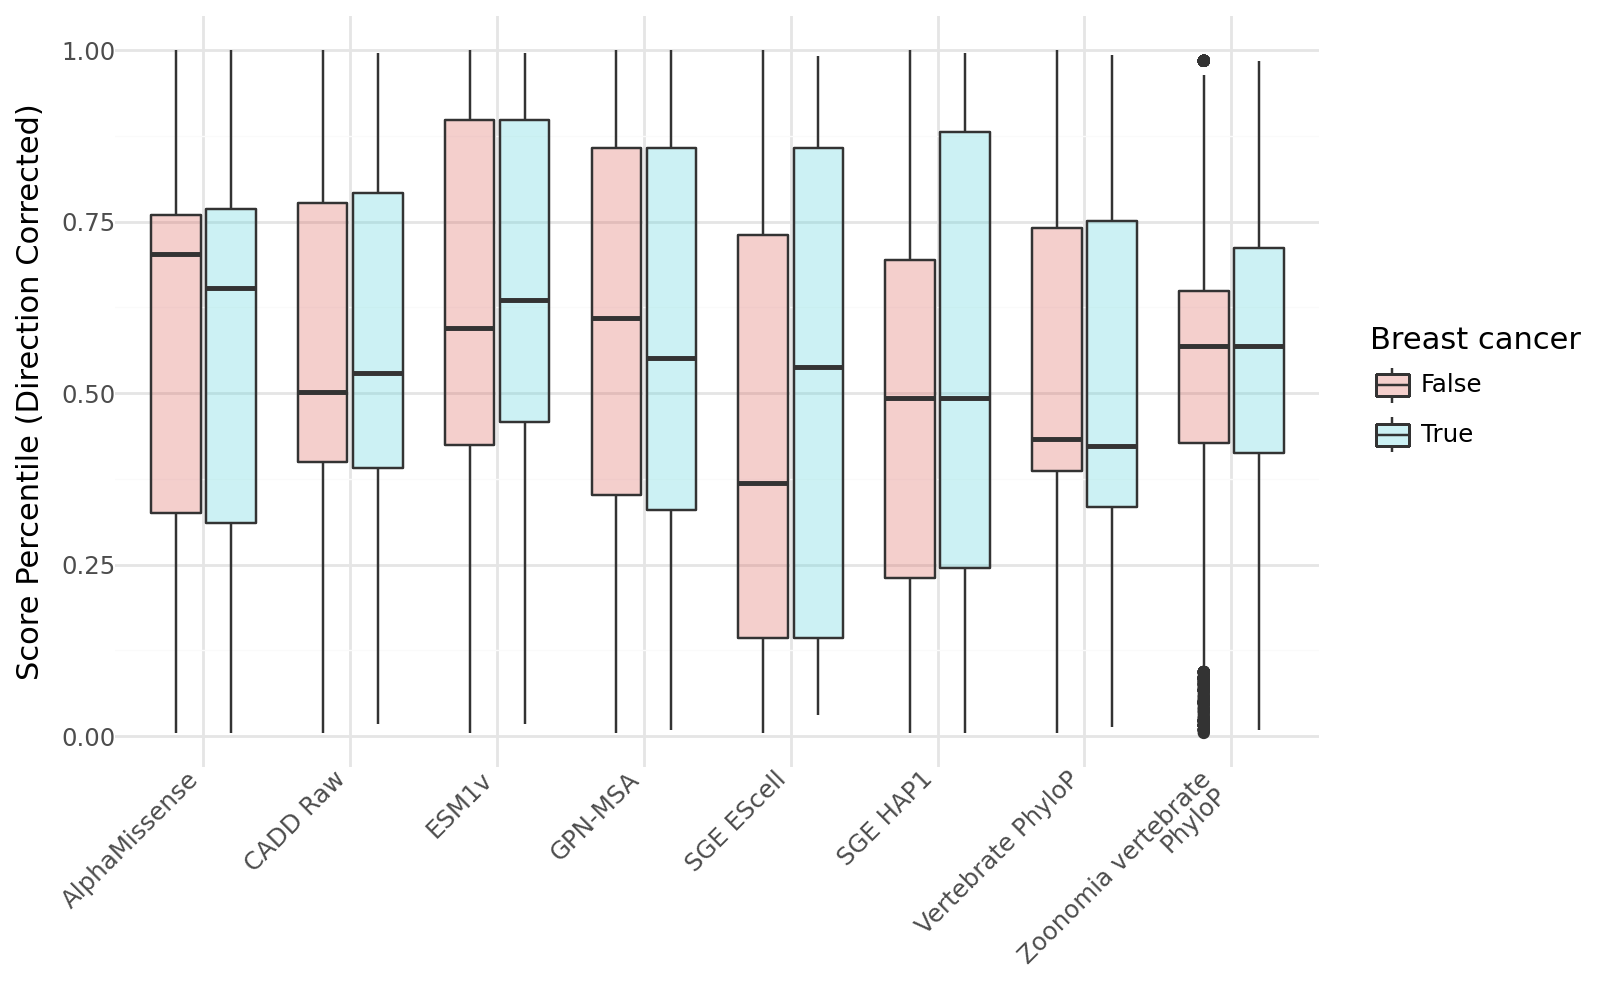

In [48]:
# annos2plot = ['am_pathogenicity', 'cadd_raw', 'gpn_score', 'SGE_HAP1', 'SGE_EScell', 'zooverphylop', 'verphylop']
# pheno_gis_dircorr.filter(pl.col('annotation').is_in(annos2plot))
plot_df = pheno_gis_dircorr.with_columns(
    pheno_bool = pl.col('pheno_value') > 0
)

(
    ggplot(plot_df, aes(x='label', y='score_ptile_dircorr', fill='pheno_bool')) +
    geom_boxplot(alpha=0.3) +
    theme_minimal() +
    labs(
        x='',
        y='Score Percentile (Direction Corrected)',
        fill='Breast cancer'
    ) +
    theme(
        figure_size=(8, 5),
        axis_text_x=element_text(rotation=45, hjust=1)
    )
)

In [49]:
pheno_gis_dircorr

id,individual,genotype,region,age,sex,phenotype,pheno_value,region_right,af_ukb,annotation,score,label,category,annotation_dir,color,n_variants,score_dircorr,individual_right,genotype_right,age_right,sex_right,pheno_value_right,region_right_right,af_ukb_right,score_right,label_right,category_right,annotation_dir_right,color_right,n_variants_right,score_dircorr_right,score_rank,score_rank_dircorr,max_score_rank,score_ptile,score_ptile_dircorr
str,str,i32,str,i8,f64,str,f32,str,f32,str,f32,str,str,i64,str,u64,f64,str,i32,i8,f64,f32,str,f32,f32,str,str,i64,str,u64,f64,f64,f64,u64,f64,f64
"""chr13:32363417:G:T""","""3760053""",1,"""ENSG00000139618""",55,0.0,"""jurgens_breast_cancer""",0.0,"""ENSG00000139618""",0.00001,"""gpn_score""",0.79,"""GPN-MSA""","""conservation""",-1,"""#942c80""",225,-0.79,"""3760053""",1,55,0.0,0.0,"""ENSG00000139618""",0.00001,0.79,"""GPN-MSA""","""conservation""",-1,"""#942c80""",225,-0.79,218.0,8.0,225,0.968889,0.035556
"""chr13:32363417:G:T""","""3760053""",1,"""ENSG00000139618""",55,0.0,"""jurgens_breast_cancer""",0.0,"""ENSG00000139618""",0.00001,"""cadd_raw""",0.922218,"""CADD Raw""","""genetic_diversity""",1,"""#1f77b4""",225,0.922218,"""3760053""",1,55,0.0,0.0,"""ENSG00000139618""",0.00001,0.922218,"""CADD Raw""","""genetic_diversity""",1,"""#1f77b4""",225,0.922218,25.0,25.0,225,0.111111,0.111111
"""chr13:32363417:G:T""","""3760053""",1,"""ENSG00000139618""",55,0.0,"""jurgens_breast_cancer""",0.0,"""ENSG00000139618""",0.00001,"""zooverphylop""",1.692,"""Zoonomia vertebrate PhyloP""","""conservation""",1,"""#6a1c81""",225,1.692,"""3760053""",1,55,0.0,0.0,"""ENSG00000139618""",0.00001,1.692,"""Zoonomia vertebrate PhyloP""","""conservation""",1,"""#6a1c81""",225,1.692,73.0,73.0,225,0.324444,0.324444
"""chr13:32363417:G:T""","""3760053""",1,"""ENSG00000139618""",55,0.0,"""jurgens_breast_cancer""",0.0,"""ENSG00000139618""",0.00001,"""am_pathogenicity""",0.0772,"""AlphaMissense""","""missense""",1,"""#e76e5b""",225,0.0772,"""3760053""",1,55,0.0,0.0,"""ENSG00000139618""",0.00001,0.0772,"""AlphaMissense""","""missense""",1,"""#e76e5b""",225,0.0772,34.0,34.0,225,0.151111,0.151111
"""chr13:32363417:G:T""","""3760053""",1,"""ENSG00000139618""",55,0.0,"""jurgens_breast_cancer""",0.0,"""ENSG00000139618""",0.00001,"""verphylop""",1.55,"""Vertebrate PhyloP""","""conservation""",1,"""#440154""",225,1.55,"""3760053""",1,55,0.0,0.0,"""ENSG00000139618""",0.00001,1.55,"""Vertebrate PhyloP""","""conservation""",1,"""#440154""",225,1.55,69.0,69.0,225,0.306667,0.306667
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""chr13:32379412:G:T""","""2133796""",1,"""ENSG00000139618""",46,0.0,"""jurgens_breast_cancer""",0.0,"""ENSG00000139618""",0.000927,"""am_pathogenicity""",0.3861,"""AlphaMissense""","""missense""",1,"""#e76e5b""",225,0.3861,"""3952115""",1,67,0.0,0.0,"""ENSG00000139618""",0.000927,0.3861,"""AlphaMissense""","""missense""",1,"""#e76e5b""",225,0.3861,168.0,168.0,225,0.746667,0.746667
"""chr13:32379412:G:T""","""2133796""",1,"""ENSG00000139618""",46,0.0,"""jurgens_breast_cancer""",0.0,"""ENSG00000139618""",0.000927,"""verphylop""",2.51,"""Vertebrate PhyloP""","""conservation""",1,"""#440154""",225,2.51,"""3952115""",1,67,0.0,0.0,"""ENSG00000139618""",0.000927,2.51,"""Vertebrate PhyloP""","""conservation""",1,"""#440154""",225,2.51,95.0,95.0,225,0.422222,0.422222
"""chr13:32379412:G:T""","""2133796""",1,"""ENSG00000139618""",46,0.0,"""jurgens_breast_cancer""",0.0,"""ENSG00000139618""",0.000927,"""esmscoremissense""",-4.83,"""ESM1v""","""missense""",-1,"""#feb72d""",225,4.83,"""3952115""",1,67,0.0,0.0,"""ENSG00000139618""",0.000927,-4.83,"""ESM1v""","""missense""",-1,"""#feb72d""",225,4.83,22.0,204.0,225,0.097778,0.906667


### AUC

In [50]:
def compute_auc(pheno_value, anno_score) -> float:
    try:
        return roc_auc_score(pheno_value, anno_score)
    except ValueError:  # e.g., only one class present
        return np.nan
    
auc_df = (
    pheno_gis_dircorr.lazy()
    .group_by(['annotation', 'label', 'phenotype', 'region'])
    .map_groups(lambda df: pl.DataFrame({
        "annotation": [df["annotation"][0]],
        "label": [df["label"][0]],
        "phenotype": [df["phenotype"][0]],
        "region": [df["region"][0]],
        "auc": [compute_auc(df['pheno_value'], df['score_dircorr'])],
        "n_variants": [df['id'].n_unique()]
        }),
        schema={"auc": pl.Float64, "n_variants": pl.Int64}
    )
    .drop_nulls(subset=['auc'])
    .sort('auc', descending=True)
).collect(engine='streaming')

auc_df

annotation,label,phenotype,region,auc,n_variants
str,str,str,str,f64,i64
"""SGE_EScell""","""SGE EScell""","""jurgens_breast_cancer""","""ENSG00000139618""",0.57679,225
"""SGE_HAP1""","""SGE HAP1""","""jurgens_breast_cancer""","""ENSG00000139618""",0.54087,225
"""esmscoremissense""","""ESM1v""","""jurgens_breast_cancer""","""ENSG00000139618""",0.520785,225
"""zooverphylop""","""Zoonomia vertebrate PhyloP""","""jurgens_breast_cancer""","""ENSG00000139618""",0.516777,225
"""cadd_raw""","""CADD Raw""","""jurgens_breast_cancer""","""ENSG00000139618""",0.511148,225
"""verphylop""","""Vertebrate PhyloP""","""jurgens_breast_cancer""","""ENSG00000139618""",0.487141,225
"""gpn_score""","""GPN-MSA""","""jurgens_breast_cancer""","""ENSG00000139618""",0.4858,225
"""am_pathogenicity""","""AlphaMissense""","""jurgens_breast_cancer""","""ENSG00000139618""",0.479151,225


In [51]:

from sklearn.metrics import roc_auc_score

def compute_auc(pheno_value: pl.Series, anno_score: pl.Series) -> float:
    try:
        if pheno_value.n_unique() < 2:
            return np.nan
        return roc_auc_score(pheno_value, anno_score)
    except ValueError:
        return np.nan

def compute_bootstrapped_auc_ci(
    df_group: pl.DataFrame, n_bootstraps: int = 1000, alpha: float = 0.05
) -> pl.DataFrame:
    """
    Performs bootstrapping on a dataframe group to calculate the mean AUC and confidence intervals.
    """
    bootstrapped_aucs = []
    for _ in range(n_bootstraps):
        # Create a bootstrap sample by sampling with replacement
        df_sample = df_group.sample(fraction=1.0, with_replacement=True)
        
        # Compute AUC for the current bootstrap sample
        auc = compute_auc(df_sample['pheno_value'], df_sample['score_dircorr'])
        
        if not np.isnan(auc):
            bootstrapped_aucs.append(auc)

    # If all bootstrap attempts failed, return NaNs
    if not bootstrapped_aucs:
        return pl.DataFrame({
            "auc_mean": [np.nan], "auc_ci_lower": [np.nan], "auc_ci_upper": [np.nan]
        })

    # Calculate mean and percentile-based confidence intervals
    # For a 95% CI (alpha=0.05), we use the 2.5th and 97.5th percentiles
    lower_p = (alpha / 2.0) * 100
    upper_p = (1.0 - alpha / 2.0) * 100
    
    auc_mean = np.mean(bootstrapped_aucs)
    auc_ci_lower = np.percentile(bootstrapped_aucs, lower_p)
    auc_ci_upper = np.percentile(bootstrapped_aucs, upper_p)
    
    # Return results as a Polars DataFrame
    return pl.DataFrame({
        "auc_mean": [auc_mean],
        "auc_ci_lower": [auc_ci_lower],
        "auc_ci_upper": [auc_ci_upper],
    })

N_BOOTSTRAPS = 1000  # Set the number of bootstrap iterations

auc_bootstrap_df = (
    pheno_gis_dircorr.lazy()
    .group_by(['annotation', 'label', 'phenotype', 'region'])
    .map_groups(
        lambda df: (
            # Run the bootstrapping function on the entire group
            compute_bootstrapped_auc_ci(df, n_bootstraps=N_BOOTSTRAPS)
            # Add back the identifier columns and variant count
            .with_columns(
                annotation=pl.lit(df["annotation"][0]),
                label=pl.lit(df["label"][0]),
                phenotype=pl.lit(df["phenotype"][0]),
                region=pl.lit(df["region"][0]),
                n_variants=pl.lit(df['id'].n_unique())
            )
        ),
        # Define the new schema for the output
        schema={
            "auc_mean": pl.Float64,
            "auc_ci_lower": pl.Float64,
            "auc_ci_upper": pl.Float64,
            "annotation": pl.String,
            "label": pl.String,
            "phenotype": pl.String,
            "region": pl.String,
            "n_variants": pl.Int64
        }
    )
    .drop_nulls(subset=['auc_mean'])
    .sort('auc_mean', descending=True)
).collect(engine='streaming')

auc_bootstrap_df

auc_mean,auc_ci_lower,auc_ci_upper,annotation,label,phenotype,region,n_variants
f64,f64,f64,str,str,str,str,i32
0.576235,0.533744,0.619261,"""SGE_EScell""","""SGE EScell""","""jurgens_breast_cancer""","""ENSG00000139618""",225
0.539961,0.491623,0.58627,"""SGE_HAP1""","""SGE HAP1""","""jurgens_breast_cancer""","""ENSG00000139618""",225
0.520507,0.47062,0.56584,"""esmscoremissense""","""ESM1v""","""jurgens_breast_cancer""","""ENSG00000139618""",225
0.517798,0.471427,0.562259,"""zooverphylop""","""Zoonomia vertebrate PhyloP""","""jurgens_breast_cancer""","""ENSG00000139618""",225
0.512814,0.466465,0.557889,"""cadd_raw""","""CADD Raw""","""jurgens_breast_cancer""","""ENSG00000139618""",225
0.487933,0.44431,0.534167,"""verphylop""","""Vertebrate PhyloP""","""jurgens_breast_cancer""","""ENSG00000139618""",225
0.484223,0.438126,0.530091,"""gpn_score""","""GPN-MSA""","""jurgens_breast_cancer""","""ENSG00000139618""",225
0.479117,0.433565,0.521772,"""am_pathogenicity""","""AlphaMissense""","""jurgens_breast_cancer""","""ENSG00000139618""",225


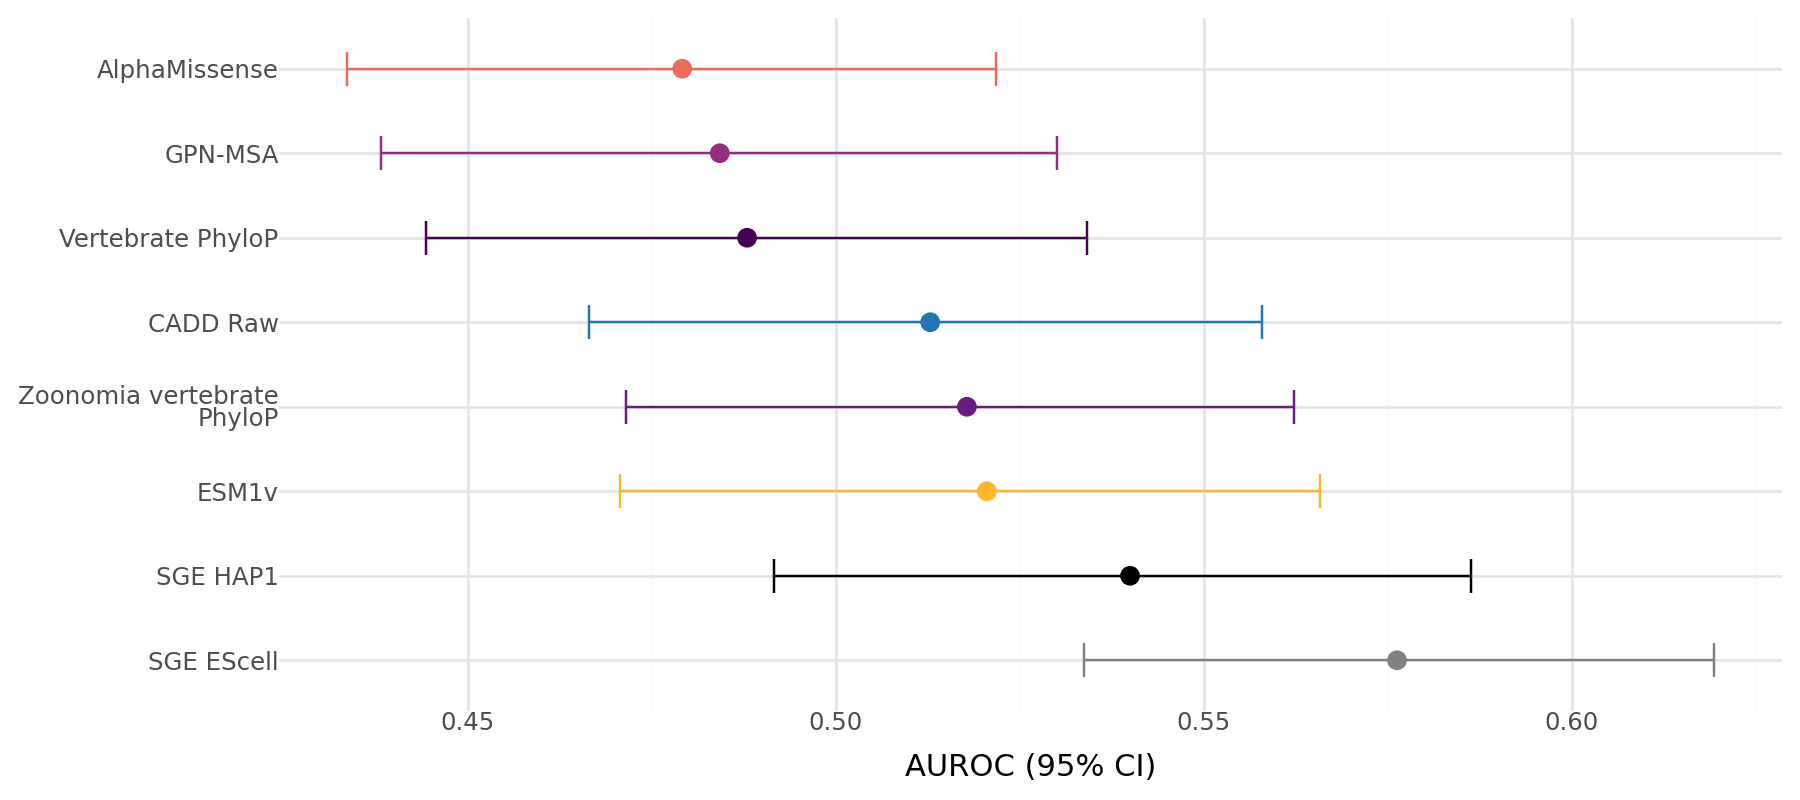

In [52]:
auc_plot_df = auc_bootstrap_df.to_pandas()

# Ordering by mean correlation
auc_plot_df['label'] = pd.Categorical(
    auc_plot_df['label'],
    categories=auc_plot_df.sort_values('auc_mean', ascending=False)['label'],
    ordered=True
)

color_dict = dict(zip(anno_config_df['label'], anno_config_df['color']))

(
    ggplot(auc_plot_df, aes(x='label', y='auc_mean', color='label')) +
    geom_point(size=3) +
    geom_errorbar(aes(ymin='auc_ci_lower', ymax='auc_ci_upper'), width=0.4) +
    coord_flip() +
    theme_minimal() +
    scale_color_manual(values=color_dict) +
    labs(
        x='',
        y='AUROC (95% CI)'
    ) +
    theme(
        figure_size=(9, 4),
        legend_position='none'
    )
)

### Odds ratio

$$
\mathrm{OR} \;=\; \frac{\dfrac{N(\text{disease}>\text{GIS}) + 1}{N(\text{not disease}>\text{GIS}) + 1}}{\dfrac{N(\text{disease}<\text{GIS}) + 1}{N(\text{not disease}<\text{GIS}) + 1}}
$$

$$
\mathrm{Enrichment} \;=\; \frac{\dfrac{N(\text{disease}>\text{GIS}) + 1}{N(\text{not disease}>\text{GIS}) + 1}}{\dfrac{N(\text{disease})}{N(\text{not disease})}}
$$

In [56]:
or_df_list = []
for p_itr in tqdm(range(pheno_gis_dircorr['n_variants'][0])):
    ptile_cutoff = p_itr/pheno_gis_dircorr['n_variants'][0]

    or_temp = (
        pheno_gis_dircorr.group_by(
            ["annotation", "label", "region", "phenotype"]
        )
        .agg(
            n_dis_above_cutoff = ((pl.col("pheno_value")==1) & (pl.col("score_ptile_dircorr")>=ptile_cutoff)).sum(),
            n_not_dis_above_cutoff = ((pl.col("pheno_value")==0) & (pl.col("score_ptile_dircorr")>=ptile_cutoff)).sum(),
            n_dis_below_cutoff = ((pl.col("pheno_value")==1) & (pl.col("score_ptile_dircorr")<ptile_cutoff)).sum(),
            n_not_dis_below_cutoff = ((pl.col("pheno_value")==0) & (pl.col("score_ptile_dircorr")<ptile_cutoff)).sum(),
            total_dis = (pl.col("pheno_value")==1).sum(),
            total_not_dis = (pl.col("pheno_value")==0).sum()
        )
        .with_columns(
            ptile_cutoff = pl.lit(ptile_cutoff),
            enrichment = ((pl.col("n_dis_above_cutoff")+1) / (pl.col("n_not_dis_above_cutoff")+1))/(pl.col("total_dis")/pl.col("total_not_dis")),
            odds_ratio = ((pl.col("n_dis_above_cutoff")+1) / (pl.col("n_dis_below_cutoff")+1)) / ((pl.col("n_not_dis_above_cutoff")+1) / (pl.col("n_not_dis_below_cutoff")+1))
        )
    )

    or_df_list.append(or_temp)

or_df = pl.concat(or_df_list)
or_df

100%|██████████| 225/225 [00:00<00:00, 626.55it/s]


annotation,label,region,phenotype,n_dis_above_cutoff,n_not_dis_above_cutoff,n_dis_below_cutoff,n_not_dis_below_cutoff,total_dis,total_not_dis,ptile_cutoff,enrichment,odds_ratio
str,str,str,str,u64,u64,u64,u64,u64,u64,f64,f64,f64
"""SGE_HAP1""","""SGE HAP1""","""ENSG00000139618""","""jurgens_breast_cancer""",185,1787,0,0,185,1787,0.0,1.004843,0.104027
"""gpn_score""","""GPN-MSA""","""ENSG00000139618""","""jurgens_breast_cancer""",185,1787,0,0,185,1787,0.0,1.004843,0.104027
"""esmscoremissense""","""ESM1v""","""ENSG00000139618""","""jurgens_breast_cancer""",185,1787,0,0,185,1787,0.0,1.004843,0.104027
"""SGE_EScell""","""SGE EScell""","""ENSG00000139618""","""jurgens_breast_cancer""",185,1787,0,0,185,1787,0.0,1.004843,0.104027
"""am_pathogenicity""","""AlphaMissense""","""ENSG00000139618""","""jurgens_breast_cancer""",185,1787,0,0,185,1787,0.0,1.004843,0.104027
…,…,…,…,…,…,…,…,…,…,…,…,…
"""SGE_HAP1""","""SGE HAP1""","""ENSG00000139618""","""jurgens_breast_cancer""",2,24,183,1763,185,1787,0.995556,1.159135,1.150435
"""cadd_raw""","""CADD Raw""","""ENSG00000139618""","""jurgens_breast_cancer""",1,8,184,1779,185,1787,0.995556,2.146547,2.138138
"""verphylop""","""Vertebrate PhyloP""","""ENSG00000139618""","""jurgens_breast_cancer""",0,2,185,1785,185,1787,0.995556,3.21982,3.200717


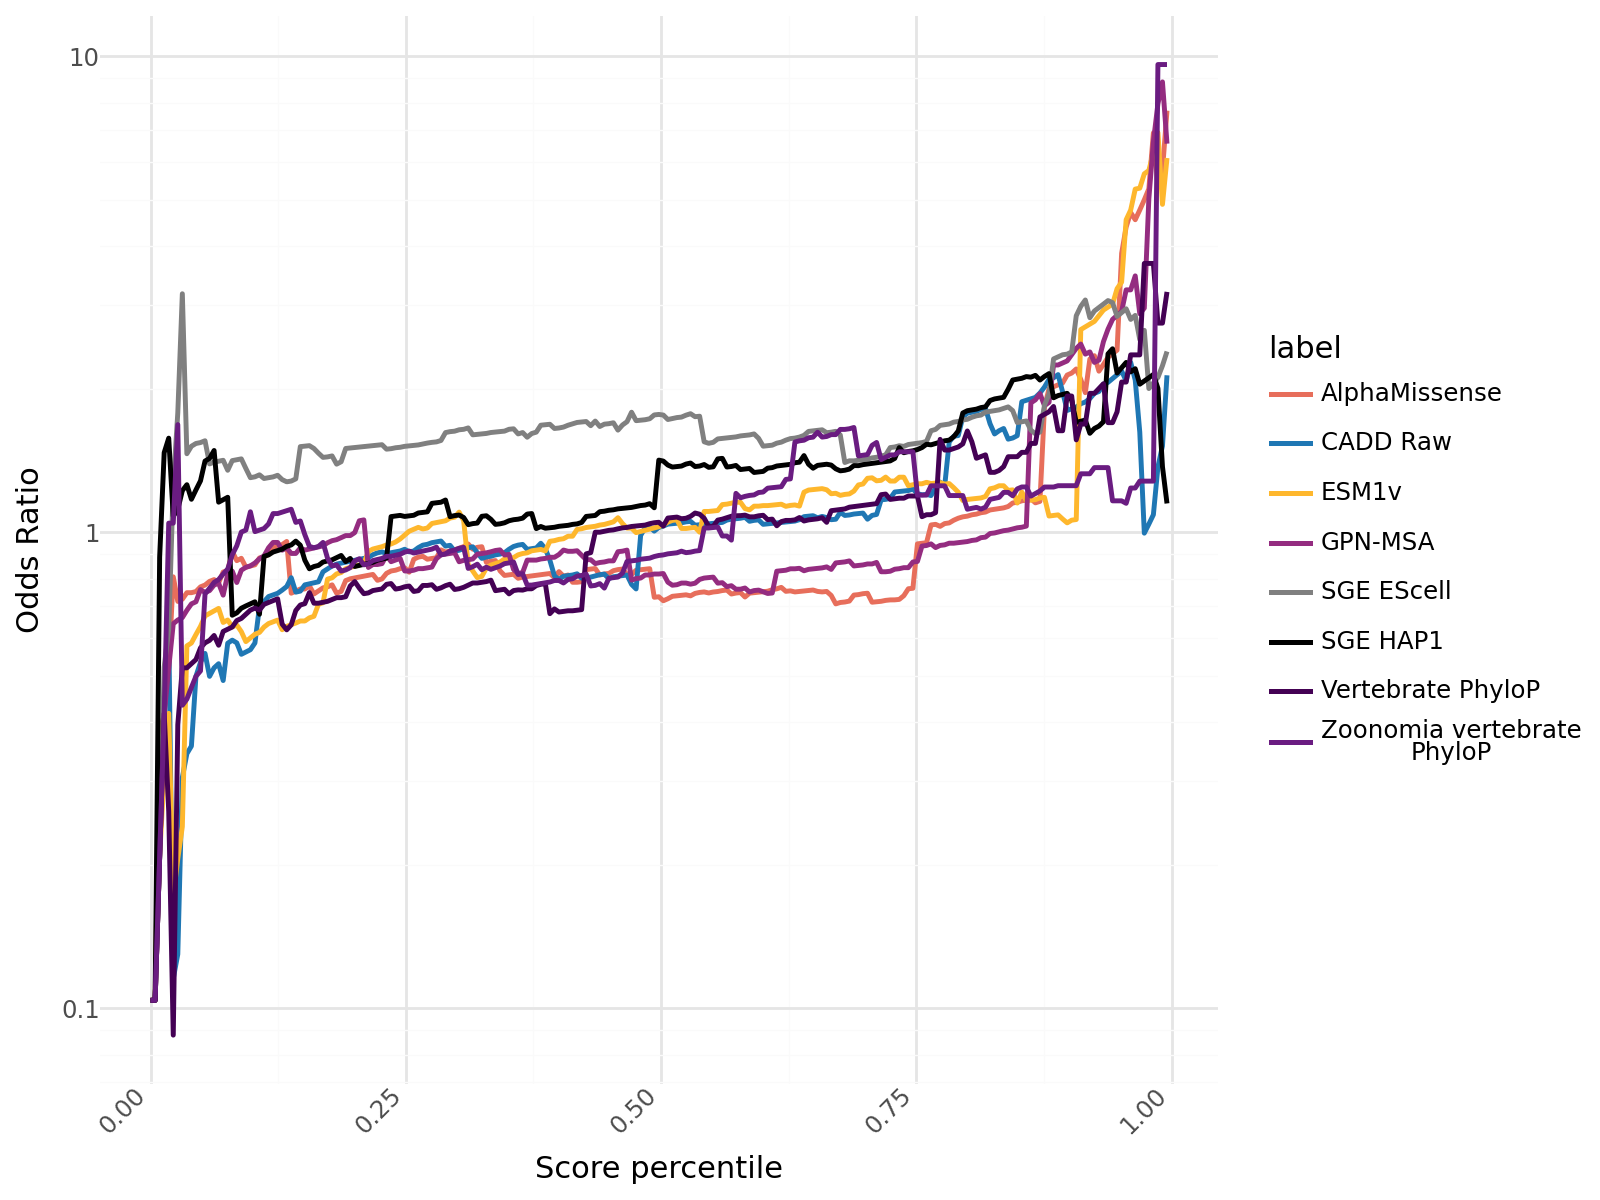

In [57]:
color_dict = dict(zip(anno_config_df['label'], anno_config_df['color']))

(
    ggplot(or_df, aes(x='ptile_cutoff', y='odds_ratio', color='label')) +
    geom_line(size=1) +
    theme_minimal() +
    scale_y_log10() +
    scale_color_manual(values=color_dict) +
    labs(
        x='Score percentile',
        y='Odds Ratio'
    ) +
    theme(
        figure_size=(8, 6),
        axis_text_x=element_text(rotation=45, hjust=1)
    )
)

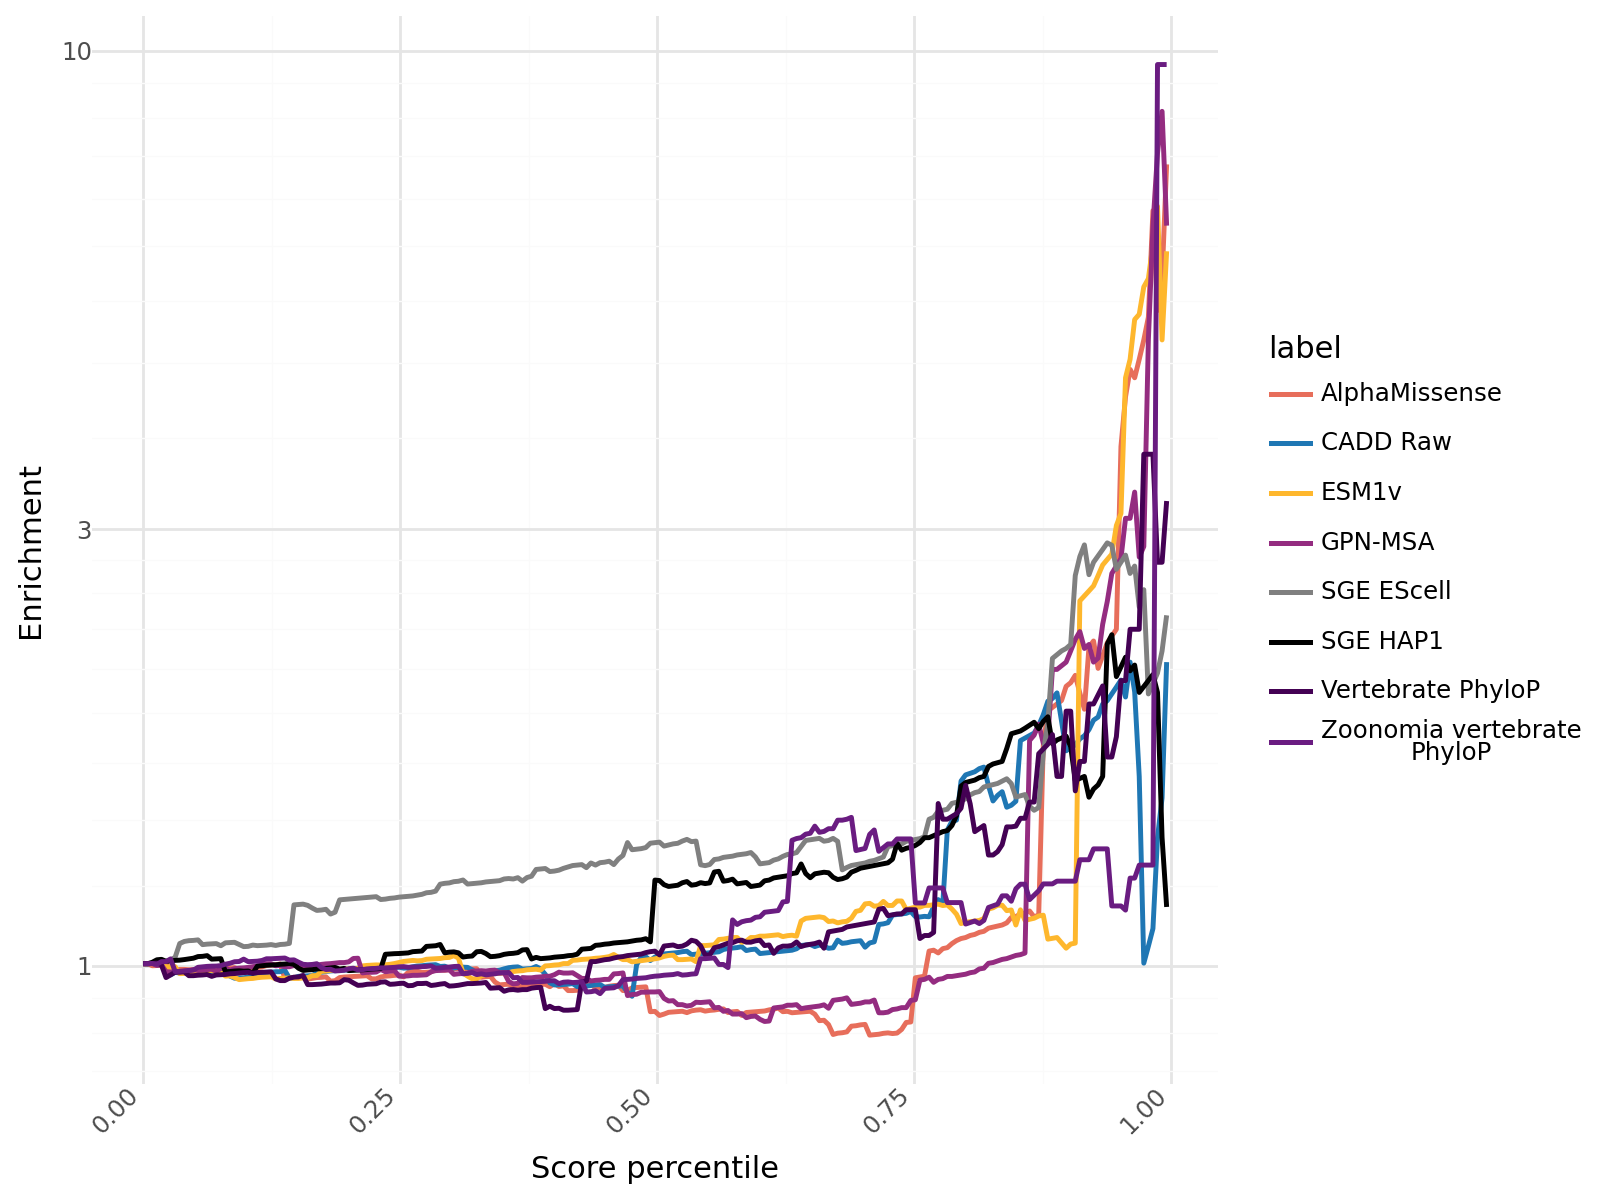

In [58]:
color_dict = dict(zip(anno_config_df['label'], anno_config_df['color']))

(
    ggplot(or_df, aes(x='ptile_cutoff', y='enrichment', color='label')) +
    geom_line(size=1) +
    theme_minimal() +
    scale_y_log10() +
    scale_color_manual(values=color_dict) +
    labs(
        x='Score percentile',
        y='Enrichment'
    ) +
    theme(
        figure_size=(8, 6),
        axis_text_x=element_text(rotation=45, hjust=1)
    )
)

## PR curve

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# (Your compute_pr_metrics function remains the same)
def compute_pr_metrics(pheno_value, anno_score) -> dict:
    try:
        precision, recall, _ = precision_recall_curve(pheno_value, anno_score)
        auprc = average_precision_score(pheno_value, anno_score)

        # Slice to remove the conventional (R=0, P=1) point from the end
        p = precision[:-1]
        r = recall[:-1]

        if p.size > 0:
            final_precision = np.concatenate([[p[0]], p]).tolist()
            final_recall = np.concatenate([[0.0], r]).tolist()
        else: # Handle empty cases
            final_precision = []
            final_recall = []

        return {
            "precision": final_precision,
            "recall": final_recall,
            "auprc": auprc
        }
    except ValueError:
        return { "precision": None, "recall": None, "auprc": np.nan }

# DEFINE THIS NEW FUNCTION
def process_group(df: pl.DataFrame) -> pl.DataFrame:
    metrics = compute_pr_metrics(df['pheno_value'], df['score_dircorr'])
    return pl.DataFrame({
        "annotation": [df["annotation"][0]],
        "label": [df["label"][0]],
        "phenotype": [df["phenotype"][0]],
        "region": [df["region"][0]],
        "precision": [metrics["precision"]],
        "recall": [metrics["recall"]],
        "auprc": [metrics["auprc"]],
        "n_variants": [df['id'].n_unique()]
    })

# The updated Polars query now calls the named function
pr_df = (
    pheno_gis_dircorr.lazy()
    .group_by(['annotation', 'label', 'phenotype', 'region'])
    # Pass the named function to map_groups instead of a lambda
    .map_groups(
        process_group,
        schema={
            "annotation": pl.String,
            "label": pl.String,
            "phenotype": pl.String,
            "region": pl.String,
            "precision": pl.List(pl.Float64),
            "recall": pl.List(pl.Float64),
            "auprc": pl.Float64,
            "n_variants": pl.Int64
        }
    )
    .drop_nulls(subset=['auprc'])
    .sort('auprc', descending=True)
).collect(streaming=True)

pr_df

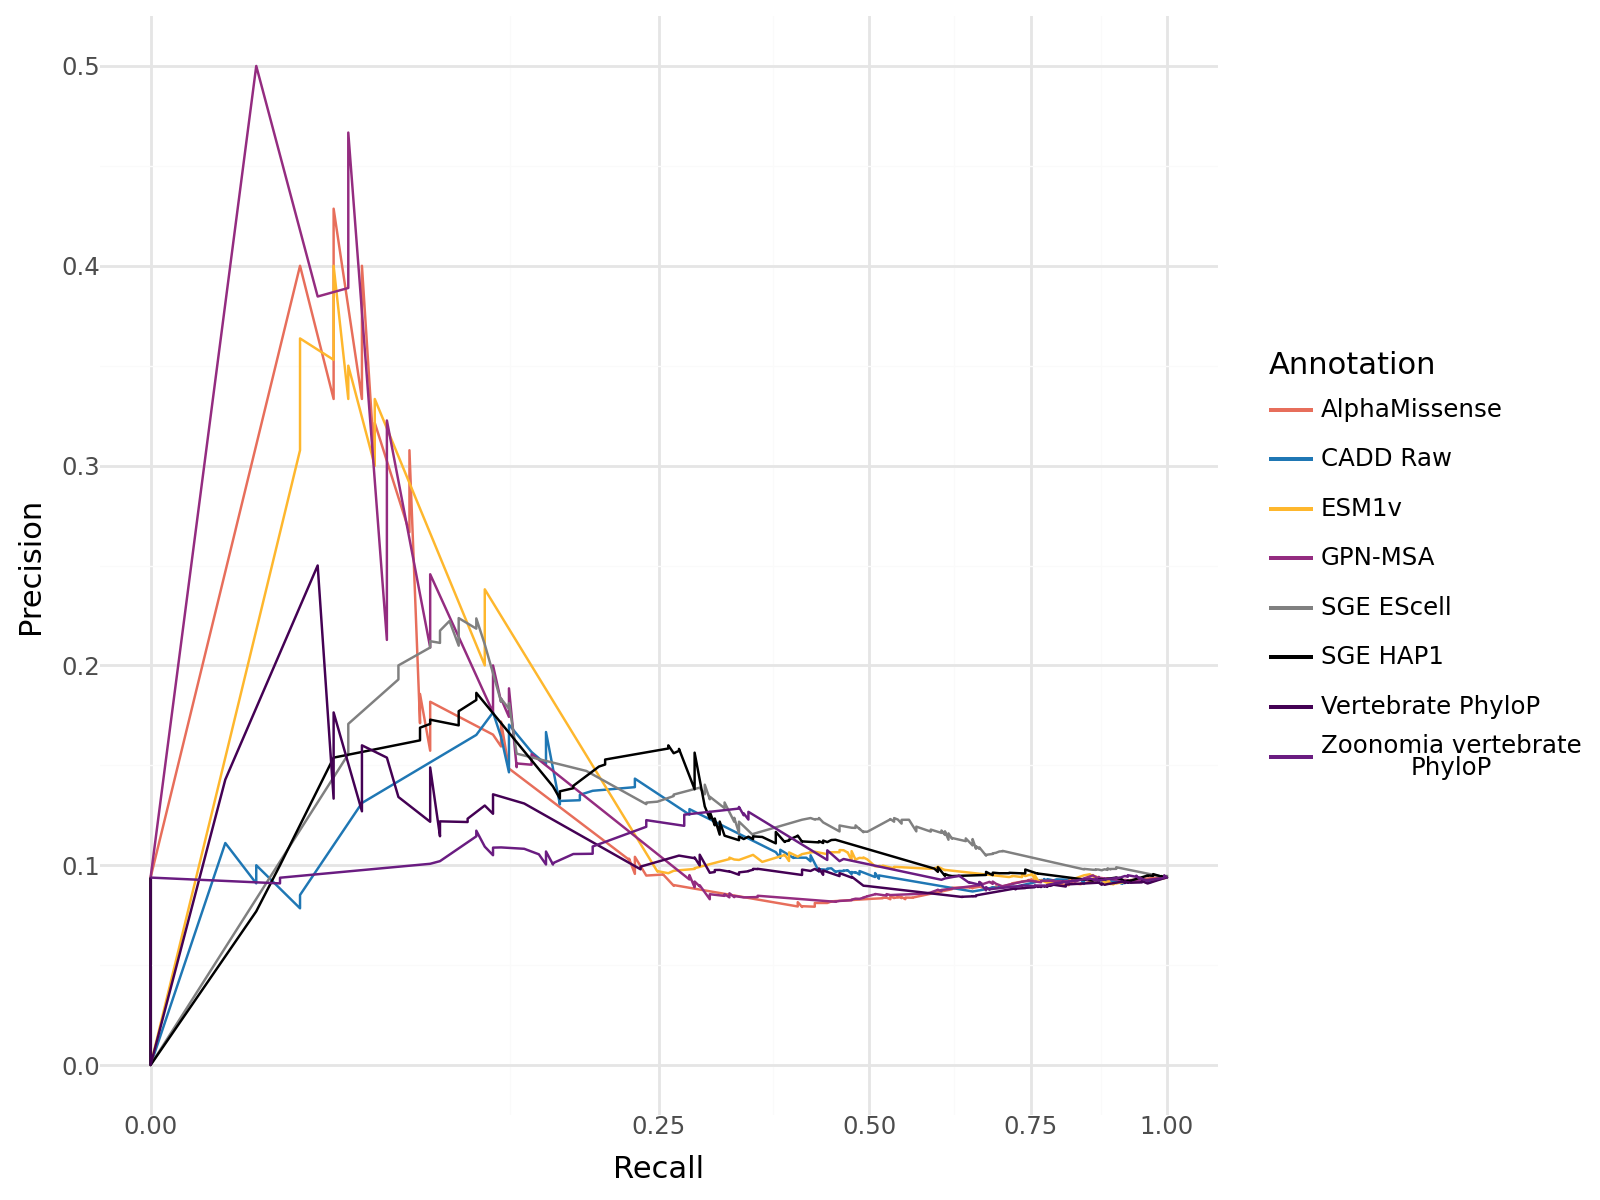

In [59]:
plot_pr_df = (
    pr_df
    .explode(['recall', 'precision'])
)

(
    ggplot(plot_pr_df, aes(x='recall', y='precision', color='label')) +
    geom_line() +
    theme_minimal() +
    scale_x_sqrt() +
    scale_color_manual(values=color_dict) +
    labs(
        x='Recall',
        y='Precision',
        color='Annotation' # Legend title
    ) +
    theme(
        figure_size=(8, 6),
    )
)

In [ ]:
#

# Old Code

### Correlations plot

### Scatter plot

In [ ]:
def plot_correlation(plot_df, phenotype, gene_id, annotation, method='spearman'):
    # Filter and add ranks
    df_filtered = plot_df.filter(
        (pl.col('phenotype') == phenotype) &
        (pl.col('region') == gene_id) &
        (pl.col('annotation') == annotation)
    ).with_columns([
        pl.col('score').rank().alias('score_rank'),
        pl.col('mean_pheno_value').rank().alias('pheno_rank')
    ])

    # Determine columns to correlate and plot
    if method.lower() == 'spearman':
        x_col, y_col = 'score_rank', 'pheno_rank'
    elif method.lower() == 'pearson':
        x_col, y_col = 'score', 'mean_pheno_value'
    else:  # Pearson
        sys.exit(f"Unrecognized method. Use 'spearman' or 'pearson'.")

    # Compute correlation using Polars
    corr = df_filtered.select([pl.corr(x_col, y_col, method='pearson')]).to_numpy()[0, 0]

    corr_text = f"{method.title()} r = {corr:.2f}"

    # Build plot
    rc_plot = (
        ggplot(df_filtered.to_pandas(), aes(x=x_col, y=y_col)) +
        geom_point(alpha=0.25) +
        geom_smooth(method='lm', se=True, color='darkred') +
        theme_minimal() +
        labs(
            x=f"{annotation} {'rank' if method.lower()=='spearman' else ''}",
            y=f"{phenotype} residual {'rank' if method.lower()=='spearman' else ''}"
        ) +
        annotate(
            'text',
            x=df_filtered[x_col].min(),
            y=df_filtered[y_col].max(),
            label=corr_text,
            ha='left',
            va='top',
            size=12
        ) +
        theme(figure_size=(5, 4))
    )

    return rc_plot

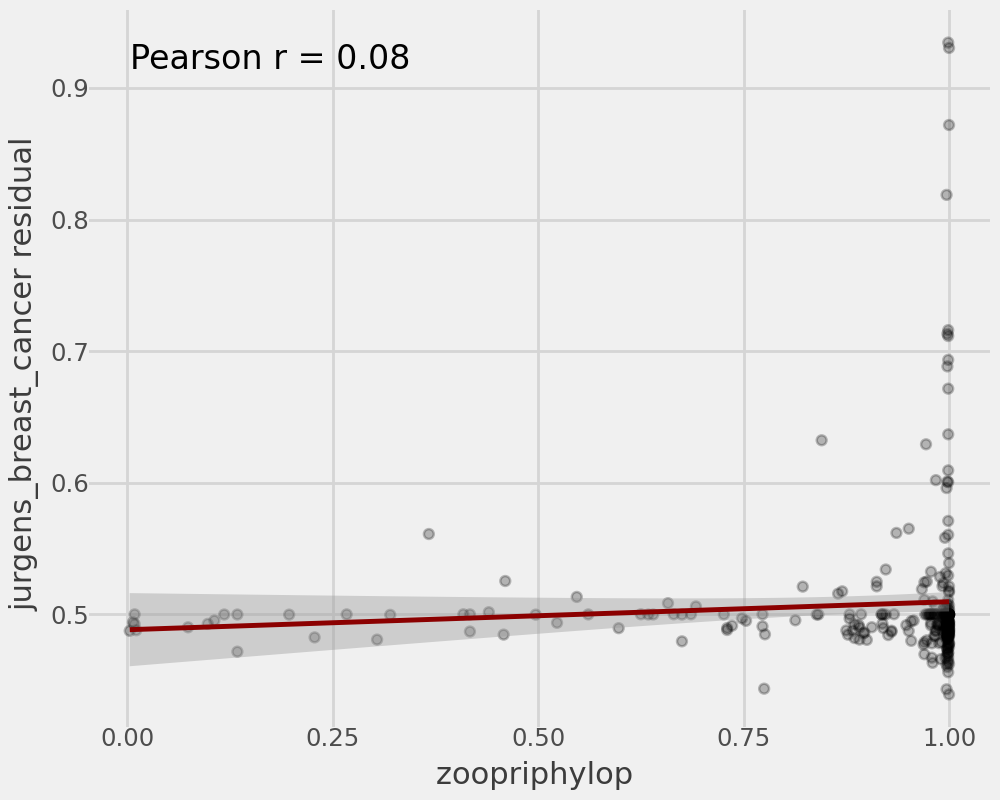

In [113]:
corr_method = 'pearson'
am_plot = plot_correlation(pheno_gis_df, gene_trait_df['phenotype'].item(), gene_trait_df['gene_id'].item(), 'zoopriphylop', method=corr_method)

am_plot

### Gene track plot

In [114]:
pheno_gis_df = pheno_gis_df.with_columns(
    pl.col('id').str.split(':').list.get(1).cast(pl.Int64).alias('pos')
)

pheno_df = pheno_gis_df[['pos', 'mean_pheno_value']].unique().sort('pos').to_pandas()
pheno_df

,pos,mean_pheno_value
0,32356428,0.492353
1,32356431,0.495157
2,32356440,0.486596
3,32356455,0.491936
4,32356458,0.494718
...,...,...
295,32396905,0.491256
296,32396907,0.499950
297,32396917,0.499954
298,32396938,0.499792


In [115]:
def plot_exon_compressed(
    pheno_df: pd.DataFrame,
    gtf_path: str,
    gene_id: str,
    gap: int = 20,
    exon_thickness: float = 0.1,
):
    """
    Plot phenotype values for variants compressed onto exons of a gene.
    """

    # --- Step 1: Read GTF, get exons for the gene ---
    gtf_cols = [
        "seqname", "source", "feature", "start", "end", "score",
        "strand", "frame", "attribute"
    ]
    gtf = pl.read_csv(
        gtf_path,
        separator="\t",
        has_header=False,
        comment_prefix="##",
        new_columns=gtf_cols
    )
    gtf = gtf.filter(pl.col("feature") == "exon")

    # Extract gene_id from the attribute field
    gtf = gtf.with_columns(
        pl.col("attribute")
        .str.extract(r'gene_id\s*"?([^";]+)"?')
        .str.split(".").list.get(0)
        .alias("gene_id")
    )
    exons = (
        gtf.filter(pl.col("gene_id") == gene_id)
        .select(["start", "end"])
        .to_pandas()
        .sort_values("start")
        .reset_index(drop=True)
    )

    if exons.empty:
        raise ValueError(f"No exons found for gene {gene_id}")

    # --- Step 2: Keep only exons that overlap with variant positions ---
    variant_positions = pheno_df["pos"].values
    exons = exons[
        exons.apply(
            lambda row: ((variant_positions >= row["start"]) & (variant_positions <= row["end"])).any(),
            axis=1,
        )
    ].reset_index(drop=True)

    if exons.empty:
        raise ValueError(f"No exons overlap with variants for gene {gene_id}")

    # --- Step 3: Build compressed coordinate mapping ---
    compressed_map = []
    current_pos = 0

    for _, row in exons.iterrows():
        length = row["end"] - row["start"] + 1
        compressed_map.append({
            "genomic_start": row["start"],
            "genomic_end": row["end"],
            "compressed_start": current_pos,
            "compressed_end": current_pos + length - 1
        })
        current_pos += length + gap

    map_df = pd.DataFrame(compressed_map)

    # --- Step 4: Map variant positions ---
    def map_pos(pos):
        for _, row in map_df.iterrows():
            if row.genomic_start <= pos <= row.genomic_end:
                return row.compressed_start + (pos - row.genomic_start)
        return None

    pheno_df = pheno_df.copy()
    pheno_df["compressed_pos"] = pheno_df["pos"].apply(map_pos)
    pheno_df = pheno_df.dropna(subset=["compressed_pos"])

    # --- Step 5: Build exon rectangles for shading ---
    exon_rects = map_df.assign(
        ymin=-exon_thickness / 2,
        ymax=exon_thickness / 2
    ).rename(columns={"compressed_start": "xmin", "compressed_end": "xmax"})

    return pheno_df, exon_rects

In [116]:
gene_id=gene_trait_df['gene_id'].item()
phenotype=gene_trait_df['phenotype'].item()

pheno_df, exon_rects = plot_exon_compressed(
    pheno_df=pheno_df,
    gtf_path='/home/dnanexus/data_dir/gencode.v48.annotation.gtf.gz',
    gene_id=gene_id,
    gap=5,
    exon_thickness=0.4,
)


plot = (
    ggplot(pheno_df, aes(x="compressed_pos", y="mean_pheno_value"))
    # + geom_line()
    + geom_segment(aes(x="compressed_pos", xend="compressed_pos", y=0, yend="mean_pheno_value"))
    + geom_rect(
        data=exon_rects,
        mapping=aes(xmin="xmin", xmax="xmax", ymin="ymin", ymax="ymax"),
        inherit_aes=False,
        alpha=0.2,
        fill="gray"
    )
    + theme_minimal()
    + theme(figure_size=(15, 4), legend_position="right")
    + labs(x="Exons (compressed)", y=f"{phenotype} residual")
)
plot

FileNotFoundError: No such file or directory (os error 2): /home/dnanexus/data_dir/gencode.v48.annotation.gtf.gz